In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("C:/Users/lavanya/Downloads/QVI_data.csv")
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

print(data['YEARMONTH'].unique())

[201810 201809 201903 201811 201812 201807 201906 201904 201901 201808
 201905 201902]


In [7]:
month_counts = metrics.groupby('STORE_NBR')['YEARMONTH'].count()
full_stores = month_counts[month_counts == 12].index
metrics_full = metrics[metrics['STORE_NBR'].isin(full_stores)]
print(len(full_stores), "stores with full history")
print(metrics_full.shape)

260 stores with full history
(3120, 6)


In [8]:
trial_stores = [77, 86, 88]
trial_period = [201902, 201903, 201904]
pre_trial_period = [m for m in metrics_full['YEARMONTH'].unique() if m not in trial_period]
print(sorted(pre_trial_period))

[np.int32(201807), np.int32(201808), np.int32(201809), np.int32(201810), np.int32(201811), np.int32(201812), np.int32(201901), np.int32(201905), np.int32(201906)]


In [12]:
trial_stores = [77, 86, 88]
trial_period = [201902, 201903, 201904]
pre_trial_period = [m for m in sorted(metrics_full['YEARMONTH'].unique()) if m < 201902]
print(pre_trial_period)

[np.int32(201807), np.int32(201808), np.int32(201809), np.int32(201810), np.int32(201811), np.int32(201812), np.int32(201901)]


In [20]:
print(pretrial_data.shape)
print(pretrial_data['STORE_NBR'].nunique())

(1820, 6)
260


In [21]:

result_77 = find_control_store(pretrial_data, 'TOT_SALES', 77)
print(result_77.shape)
print(result_77.head(10))

(259, 6)
     STORE_NBR      CORR        DIST  DIST_SCORE  CORR_SCORE  FINAL_SCORE
220        233  0.903774   18.828571    1.000000    0.951887     0.975944
38          41  0.783232   45.342857    0.977927    0.891616     0.934771
46          50  0.763866   34.714286    0.986775    0.881933     0.934354
15          17  0.842668  155.614286    0.886125    0.921334     0.903730
158        167  0.657110   53.485714    0.971148    0.828555     0.899851
251        265  0.639759   48.271429    0.975489    0.819880     0.897684
107        115  0.689159   87.657143    0.942700    0.844579     0.893640
49          53  0.532764   32.471429    0.988642    0.766382     0.877512
221        234  0.696325  143.685714    0.896056    0.848162     0.872109
103        111  0.519473   45.171429    0.978069    0.759736     0.868903


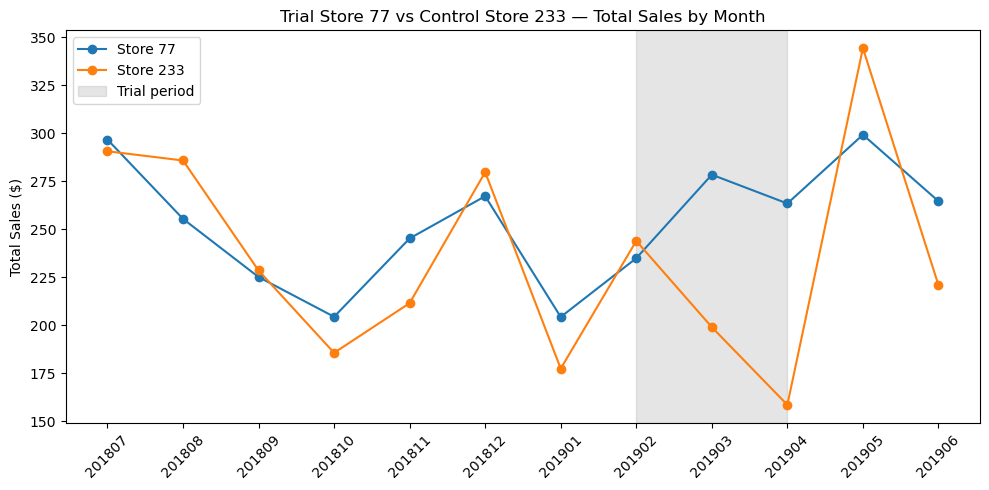

In [22]:
plt.figure(figsize=(10, 5))
for store in [77, 233]:
    store_data = metrics_full[metrics_full['STORE_NBR'] == store].sort_values('YEARMONTH')
    plt.plot(store_data['YEARMONTH'].astype(str), store_data['TOT_SALES'], marker='o', label=f'Store {store}')

plt.axvspan('201902', '201904', color='gray', alpha=0.2, label='Trial period')
plt.xticks(rotation=45)
plt.legend()
plt.title('Trial Store 77 vs Control Store 233 — Total Sales by Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('trial77_vs_control233_sales.png')
plt.show()

In [23]:
result_86 = find_control_store(pretrial_data, 'TOT_SALES', 86)
print(result_86.head(5))

result_88 = find_control_store(pretrial_data, 'TOT_SALES', 88)
print(result_88.head(5))

     STORE_NBR      CORR       DIST  DIST_SCORE  CORR_SCORE  FINAL_SCORE
146        155  0.877882  32.464286    0.998964    0.938941     0.968952
101        109  0.788300  31.607143    1.000000    0.894150     0.947075
209        222  0.795075  35.864286    0.994853    0.897538     0.946195
129        138  0.759864  65.435714    0.959103    0.879932     0.919517
106        114  0.734415  68.757143    0.955087    0.867208     0.911147
     STORE_NBR      CORR        DIST  DIST_SCORE  CORR_SCORE  FINAL_SCORE
193        203  0.508001   66.100000    0.993943    0.754001     0.873972
116        125  0.624109  196.550000    0.890950    0.812054     0.851502
191        201  0.492735  169.742857    0.912115    0.746367     0.829241
224        237  0.308479   58.428571    1.000000    0.654240     0.827120
6            7  0.649657  295.728571    0.812646    0.824828     0.818737


C:\Users\lavanya\AppData\Local\Temp\ipykernel_2360\3736480705.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(store_data['YEARMONTH'].astype(str), rotation=45)
C:\Users\lavanya\AppData\Local\Temp\ipykernel_2360\3736480705.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(store_data['YEARMONTH'].astype(str), rotation=45)


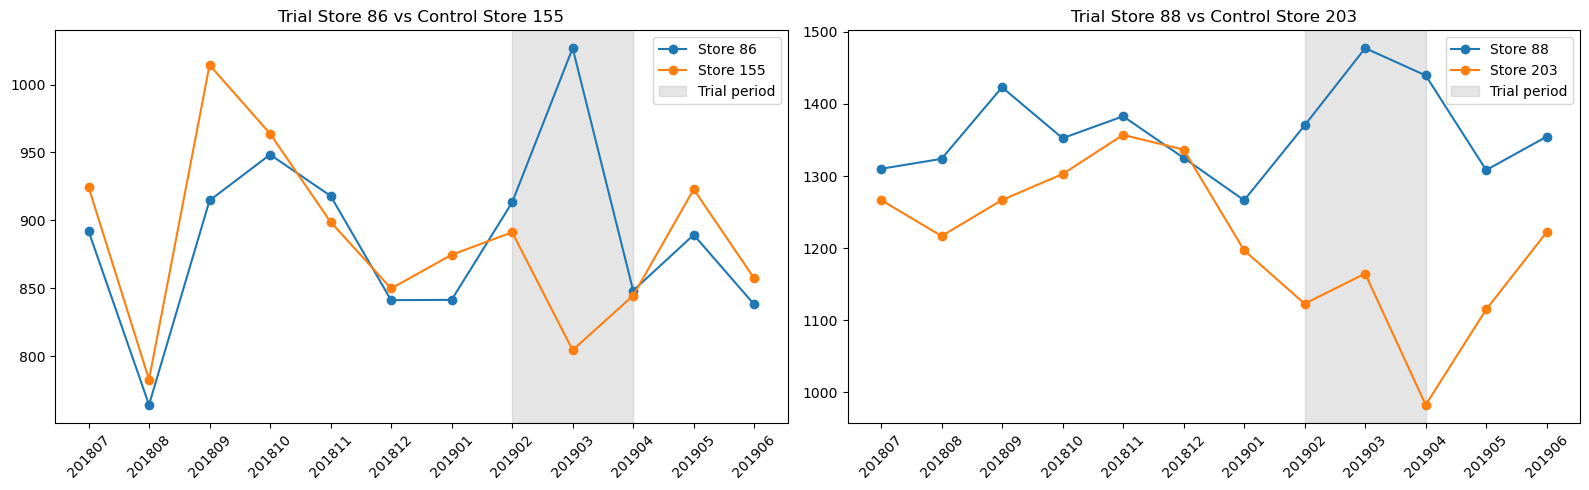

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pairs = [(86, 155, axes[0]), (88, 203, axes[1])]

for trial, control, ax in pairs:
    for store in [trial, control]:
        store_data = metrics_full[metrics_full['STORE_NBR'] == store].sort_values('YEARMONTH')
        ax.plot(store_data['YEARMONTH'].astype(str), store_data['TOT_SALES'], marker='o', label=f'Store {store}')
    ax.axvspan('201902', '201904', color='gray', alpha=0.2, label='Trial period')
    ax.set_title(f'Trial Store {trial} vs Control Store {control}')
    ax.set_xticklabels(store_data['YEARMONTH'].astype(str), rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig('trial86_88_vs_controls_sales.png')
plt.show()

In [25]:
from scipy import stats

def assess_trial_significance(metrics_full, metric_col, trial_store, control_store, pre_trial_period, trial_period):
    trial_data = metrics_full[metrics_full['STORE_NBR'] == trial_store].set_index('YEARMONTH')[metric_col]
    control_data = metrics_full[metrics_full['STORE_NBR'] == control_store].set_index('YEARMONTH')[metric_col]

    # Scaling factor based on pre-trial averages
    scaling_factor = trial_data.loc[pre_trial_period].mean() / control_data.loc[pre_trial_period].mean()
    scaled_control = control_data * scaling_factor

    # % difference in pre-trial period (to measure normal variability)
    pct_diff_pretrial = (trial_data.loc[pre_trial_period] - scaled_control.loc[pre_trial_period]) / scaled_control.loc[pre_trial_period]
    std_dev = pct_diff_pretrial.std()

    # % difference during trial period
    pct_diff_trial = (trial_data.loc[trial_period] - scaled_control.loc[trial_period]) / scaled_control.loc[trial_period]

    # t-value for each trial month
    degrees_freedom = len(pre_trial_period) - 1
    t_values = pct_diff_trial / std_dev

    results = pd.DataFrame({
        'YEARMONTH': trial_period,
        'PCT_DIFF': pct_diff_trial.values,
        'T_VALUE': t_values.values
    })
    critical_t = stats.t.ppf(0.95, degrees_freedom)
    results['SIGNIFICANT'] = results['T_VALUE'].abs() > critical_t

    return results, critical_t

result, crit_t = assess_trial_significance(metrics_full, 'TOT_SALES', 77, 233, pre_trial_period, trial_period)
print(f"Critical t-value (95% confidence): {crit_t:.3f}")
print(result)

Critical t-value (95% confidence): 1.943
   YEARMONTH  PCT_DIFF   T_VALUE  SIGNIFICANT
0     201902 -0.059107 -0.593520        False
1     201903  0.366521  3.680430         True
2     201904  0.623080  6.256669         True


In [26]:
result_86, crit_t_86 = assess_trial_significance(metrics_full, 'TOT_SALES', 86, 155, pre_trial_period, trial_period)
print("Store 86 vs Control 155")
print(f"Critical t-value: {crit_t_86:.3f}")
print(result_86)

result_88, crit_t_88 = assess_trial_significance(metrics_full, 'TOT_SALES', 88, 203, pre_trial_period, trial_period)
print("\nStore 88 vs Control 203")
print(f"Critical t-value: {crit_t_88:.3f}")
print(result_88)

Store 86 vs Control 155
Critical t-value: 1.943
   YEARMONTH  PCT_DIFF   T_VALUE  SIGNIFICANT
0     201902  0.056306  1.494114        False
1     201903  0.315870  8.381769         True
2     201904  0.035253  0.935444        False

Store 88 vs Control 203
Critical t-value: 1.943
   YEARMONTH  PCT_DIFF   T_VALUE  SIGNIFICANT
0     201902  0.162926  3.878553         True
1     201903  0.208748  4.969379         True
2     201904  0.395931  9.425411         True


In [27]:
for store, control in [(77, 233), (86, 155), (88, 203)]:
    print(f"\n--- Store {store} vs Control {control}: N_CUSTOMERS ---")
    res, _ = assess_trial_significance(metrics_full, 'N_CUSTOMERS', store, control, pre_trial_period, trial_period)
    print(res)

    print(f"--- Store {store} vs Control {control}: AVG_TXN_PER_CUSTOMER ---")
    res2, _ = assess_trial_significance(metrics_full, 'AVG_TXN_PER_CUSTOMER', store, control, pre_trial_period, trial_period)
    print(res2)


--- Store 77 vs Control 233: N_CUSTOMERS ---
   YEARMONTH  PCT_DIFF    T_VALUE  SIGNIFICANT
0     201902 -0.003344  -0.121884        False
1     201903  0.245819   8.958446         True
2     201904  0.561427  20.460197         True
--- Store 77 vs Control 233: AVG_TXN_PER_CUSTOMER ---
   YEARMONTH  PCT_DIFF   T_VALUE  SIGNIFICANT
0     201902 -0.057547 -1.173564        False
1     201903  0.056365  1.149450        False
2     201904 -0.057547 -1.173564        False

--- Store 86 vs Control 155: N_CUSTOMERS ---
   YEARMONTH  PCT_DIFF    T_VALUE  SIGNIFICANT
0     201902  0.126316   6.592964         True
1     201903  0.223404  11.660429         True
2     201904  0.060606   3.163291         True
--- Store 86 vs Control 155: AVG_TXN_PER_CUSTOMER ---
   YEARMONTH  PCT_DIFF   T_VALUE  SIGNIFICANT
0     201902  0.006959  0.101379        False
1     201903 -0.003726 -0.054277        False
2     201904  0.017040  0.248243        False

--- Store 88 vs Control 203: N_CUSTOMERS ---
   YEARMON

In [ ]:
Recommendation to Julia: The trial was successful in increasing chip category sales at all three locations, driven by attracting more customers rather
than increasing basket size. Given the consistency of the customer-acquisition effect, the trial approach appears to have genuine commercial merit and
is a reasonable candidate for wider rollout. Store 88's result should be treated with slightly less confidence given the weaker control-store match
— a stronger control from a broader store pool would help validate this location further before scaling.